<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# Supervised & Unsupervised Learning – Regression und Clustering

Dieses Notebook zeigt einfache Beispiele für:

- **Supervised Learning (Regression)** – Vorhersage eines kontinuierlichen Werts  
- **Unsupervised Learning (Clustering)** – Finden von Gruppen in Daten ohne Labels  

Verwendete Bibliotheken: `numpy`, `pandas`, `matplotlib`, `scikit-learn`.


In [1]:
# Installation (nur ausführen, falls Pakete fehlen)
# !pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.datasets import make_regression, make_blobs
from sklearn.cluster import KMeans

%matplotlib inline

## 1. Supervised Learning – Regression

Wir erzeugen einen synthetischen Datensatz mit `make_regression` und trainieren ein lineares Regressionsmodell.

**Ziel:**  
Gegeben \(x\) wollen wir einen kontinuierlichen Wert \(y\) vorhersagen.


In [2]:
# Datensatz erzeugen
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=15.0,
    random_state=42
)

df_reg = pd.DataFrame(X, columns=["x"])
df_reg["y"] = y
df_reg.head()

,x,y
0,1.852278,143.450823
1,0.473592,54.639848
2,-1.230864,-84.442236
3,0.625667,59.326531
4,-0.072010,-8.244156


In [3]:
# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    df_reg[["x"]], df_reg["y"], test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Koeffizient:", model.coef_[0])
print("Bias:", model.intercept_)

Koeffizient: 86.81798328085434
Bias: 1.8345766385094249


In [10]:
# Vorhersage und Metriken
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R²-Score:", r2)



SyntaxError: unterminated string literal (detected at line 10) (4294209752.py, line 10)

```
- MSE	Bedeutung
0	perfekte Vorhersage
klein	gute Vorhersagen
groß	schlechte Vorhersagen

R²-Score:
    0.9 | sehr gut
0.7–0.9 | gut
0.5–0.7 | mittel
  < 0.5 | schwach
```

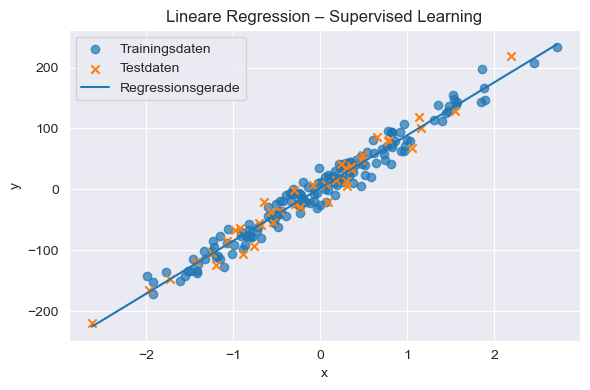

In [5]:
# Visualisierung: Datenpunkte + Regressionsgerade
plt.figure(figsize=(6, 4))
plt.scatter(X_train, y_train, alpha=0.7, label="Trainingsdaten")
plt.scatter(X_test, y_test, marker="x", label="Testdaten")

x_line = np.linspace(df_reg["x"].min(), df_reg["x"].max(), 100).reshape(-1, 1)
x_line = pd.DataFrame(x_line, columns=["x"])
y_line = model.predict(x_line)
plt.plot(x_line, y_line, label="Regressionsgerade")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Lineare Regression – Supervised Learning")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Unsupervised Learning – Clustering (K-Means)

Wir erzeugen einen 2D-Datensatz mit `make_blobs` und lassen `KMeans` drei Cluster finden.

**Wichtig:**  
Hier gibt es **keine Labels** – das Modell versucht selbst, Gruppen zu entdecken.


In [14]:
# Datensatz für Clustering erzeugen
X_clust, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.80,
    random_state=42
)

df_clust = pd.DataFrame(X_clust, columns=["x1", "x2"])
df_clust.head()

,x1,x2
0,-7.017435,-7.135063
1,-7.137751,-6.995476
2,-2.262434,8.648033
3,4.574574,2.302803
4,-7.491065,-7.182535


In [15]:
# K-Means-Clustering mit k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(df_clust[["x1", "x2"]])

df_clust["cluster"] = clusters
df_clust.head()

,x1,x2,cluster
0,-7.017435,-7.135063,1
1,-7.137751,-6.995476,1
2,-2.262434,8.648033,0
3,4.574574,2.302803,2
4,-7.491065,-7.182535,1


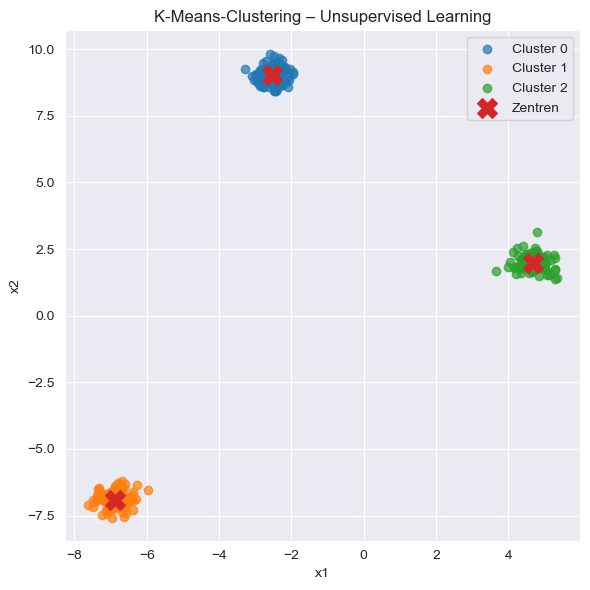

In [16]:
# Visualisierung der Cluster
plt.figure(figsize=(6, 6))

for c in sorted(df_clust["cluster"].unique()):
    subset = df_clust[df_clust["cluster"] == c]
    plt.scatter(subset["x1"], subset["x2"], label=f"Cluster {c}", alpha=0.7)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=200, label="Zentren")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("K-Means-Clustering – Unsupervised Learning")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Zusammenfassung

In diesem Notebook haben wir gesehen:

- **Supervised Learning (Regression):**
  - Gelabelte Daten (x, y)
  - Ziel: Einen kontinuierlichen Wert vorhersagen
  - Beispiel: Lineare Regression auf synthetischen Daten

- **Unsupervised Learning (Clustering):**
  - Keine Labels vorhanden
  - Ziel: Ähnliche Datenpunkte zu Gruppen (Clustern) zusammenfassen
  - Beispiel: K-Means auf 2D-Blobs
